In [0]:
%sh
mkdir -p /tmp/nyctaxi/
wget -q -O /tmp/nyctaxi/taxi_zone_lookup.csv https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv
for i in {01..12}; do
  echo "Loading data month at $i..."
  wget -q -O /tmp/nyctaxi/yellow_tripdata_2019-$i.parquet https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-$i.parquet
done

echo "Complete download 12 month!"

Loading data month at 01...
Loading data month at 02...
Loading data month at 03...
Loading data month at 04...
Loading data month at 05...
Loading data month at 06...
Loading data month at 07...
Loading data month at 08...
Loading data month at 09...
Loading data month at 10...
Loading data month at 11...
Loading data month at 12...
Complete download 12 month!


In [0]:
trips_df = spark.read.parquet("file:/tmp/nyctaxi/yellow_tripdata_2019-*.parquet")

# CSV Lookup
zones_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:/tmp/nyctaxi/taxi_zone_lookup.csv")

print(f"Total number of Big Data records collected: {trips_df.count():,} rows.")

Total number of Big Data records collected: 84,598,444 rows.


In [0]:
# Check Schema of Taxi trip
print("--- TRIP DATA SCHEMA ---")
trips_df.printSchema()

# Check Schema of Taxi Zone Lookup
print("--- ZONES DATA SCHEMA ---")
zones_df.printSchema()

--- TRIP DATA SCHEMA ---
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: integer (nullable = true)

--- ZONES DATA SCHEMA ---
root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable

In [0]:
from pyspark.sql.functions import col, year, sum, when

# 1. Data Quality
quality_metrics = trips_df.select(
    sum(when(col("trip_distance") <= 0, 1).otherwise(0)).alias("zero_distance"),
    sum(when(col("fare_amount") <= 0, 1).otherwise(0)).alias("negative_fare"),
    sum(when(col("passenger_count") <= 0, 1).otherwise(0)).alias("wrong_passenger"),
    sum(when(year(col("tpep_pickup_datetime")) != 2019, 1).otherwise(0)).alias("wrong_date")
).collect()[0]

print(f"Total original records: {trips_df.count():,}")
print(f"Number of trips having zero or negative distance: {quality_metrics['zero_distance']:,}")
print(f"Number of trips having negative or zero fare: {quality_metrics['negative_fare']:,}")
print(f"Number of trips having wrong passenger count: {quality_metrics['wrong_passenger']:,}")
print(f"Number of trips having wrong date (not 2019): {quality_metrics['wrong_date']:,}")

# 2. Data Cleansing
cleaned_trips_df = trips_df.filter(
    (col("trip_distance") > 0) & 
    (col("fare_amount") > 0) & 
    (col("total_amount") > 0) &
    (col("passenger_count") > 0) &
    (year(col("tpep_pickup_datetime")) == 2019)
)

print(f"-> Total number of CLEANED records: {cleaned_trips_df.count():,}")

Total original records: 84,598,444
Number of trips having zero or negative distance: 752,760
Number of trips having negative or zero fare: 205,121
Number of trips having wrong passenger count: 1,525,798
Number of trips having wrong date (not 2019): 1,442
-> Total number of CLEANED records: 81,749,715


In [0]:
# Register from DataFrame to Temporary Views
cleaned_trips_df.createOrReplaceTempView("cleaned_trips")
zones_df.createOrReplaceTempView("taxi_zones")

In [0]:
%sql
SELECT 
    fare_amount, 
    COUNT(*) AS total_trips, 
    ROUND(AVG(trip_distance), 2) AS avg_distance
FROM cleaned_trips
WHERE trip_distance BETWEEN 15 AND 25
GROUP BY fare_amount
ORDER BY total_trips DESC
LIMIT 5;

fare_amount,total_trips,avg_distance
52.0,1875457,18.38
45.0,20286,15.95
44.5,19620,15.85
45.5,19464,16.04
44.0,19187,15.74


In [0]:
%sql
CREATE OR REPLACE TEMP VIEW enriched_trips AS

WITH calculated_metrics AS (
    SELECT 
        t.*,
        z.Zone AS Pickup_Zone,
        z.Borough AS Pickup_Borough,
        (t.fare_amount / t.trip_distance) AS fare_per_mile,
        
    
        (t.trip_distance / ((UNIX_TIMESTAMP(t.tpep_dropoff_datetime) - UNIX_TIMESTAMP(t.tpep_pickup_datetime)) / 3600.0)) AS speed_mph,
        
        MONTH(t.tpep_pickup_datetime) AS pickup_month,
        
        -- Clasify Peak / Off-Peak
        CASE 
            WHEN DAYOFWEEK(t.tpep_pickup_datetime) BETWEEN 2 AND 6 
                 AND (HOUR(t.tpep_pickup_datetime) BETWEEN 7 AND 10 
                      OR HOUR(t.tpep_pickup_datetime) BETWEEN 16 AND 19)
            THEN 'Peak' 
            ELSE 'Off-Peak' 
        END AS is_peak
        
    FROM cleaned_trips t
    JOIN taxi_zones z ON t.PULocationID = z.LocationID
    
    -- Make sure dropoff > pickup (Divide by 0)
    WHERE (UNIX_TIMESTAMP(t.tpep_dropoff_datetime) - UNIX_TIMESTAMP(t.tpep_pickup_datetime)) > 0
)

SELECT * FROM calculated_metrics
WHERE 
    trip_distance > 0.1 
    AND fare_amount >= 2.50         -- Minimum entrance fee
    AND fare_per_mile BETWEEN 1 AND 100 -- Define a reasonable fare range per mile.
    AND speed_mph BETWEEN 2 AND 80;     -- Filter out unreasonable speeds (heavy traffic jams or speeding).

In [0]:
%sql
-- Compare Zone base on Median and IQR
SELECT 
    Pickup_Zone,
    Pickup_Borough,
    COUNT(*) AS total_trips,
    ROUND(percentile_approx(fare_per_mile, 0.5), 2) AS median_fare_per_mile,
    ROUND(percentile_approx(fare_per_mile, 0.75) - percentile_approx(fare_per_mile, 0.25), 2) AS iqr_fare_per_mile
FROM enriched_trips
GROUP BY Pickup_Zone, Pickup_Borough
HAVING total_trips > 100 -- Only filter enough data zone
ORDER BY median_fare_per_mile DESC; 

Pickup_Zone,Pickup_Borough,total_trips,median_fare_per_mile,iqr_fare_per_mile
Randalls Island,Manhattan,5731,7.28,8.55
Maspeth,Queens,6187,7.08,4.55
Astoria Park,Queens,1079,6.87,5.63
Upper East Side South,Manhattan,3536992,6.25,2.71
Midtown Center,Manhattan,3332592,6.13,3.13
Garment District,Manhattan,1656381,6.1,2.99
Flatiron,Manhattan,1416220,6.06,2.65
Penn Station/Madison Sq West,Manhattan,2913344,6.04,2.9
Union Sq,Manhattan,2455770,6.03,2.53
Midtown North,Manhattan,2179852,6.0,2.88


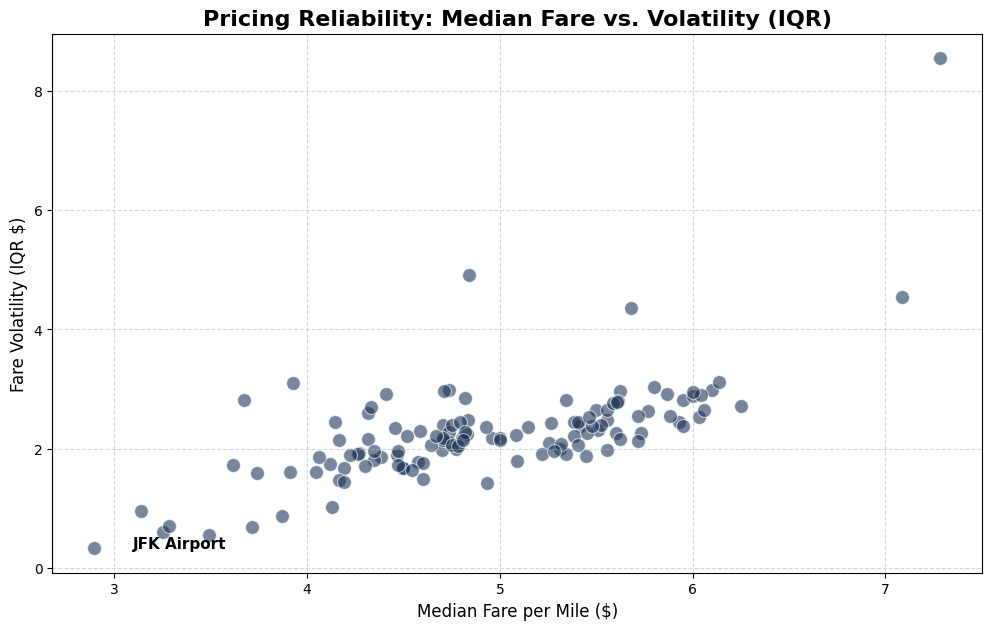

In [0]:
%python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query_plot = """
    SELECT 
        Pickup_Zone,
        median_fare_per_mile,
        iqr_fare_per_mile
    FROM (
        SELECT Pickup_Zone, COUNT(*) as total_trips,
               percentile_approx(fare_per_mile, 0.5) as median_fare_per_mile,
               percentile_approx(fare_per_mile, 0.75) - percentile_approx(fare_per_mile, 0.25) as iqr_fare_per_mile
        FROM enriched_trips
        GROUP BY Pickup_Zone
    ) 
    WHERE total_trips > 5000
"""
df_plot = spark.sql(query_plot).toPandas()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_plot, x='median_fare_per_mile', y='iqr_fare_per_mile', alpha=0.6, s=100, color='#1D3557')

for i in range(df_plot.shape[0]):
    zone = df_plot.Pickup_Zone[i]
    if zone in ['JFK Airport', 'Newark Airport']:
        plt.text(df_plot.median_fare_per_mile[i]+0.2, df_plot.iqr_fare_per_mile[i], zone, fontsize=11, fontweight='bold')

plt.title('Pricing Reliability: Median Fare vs. Volatility (IQR)', fontsize=16, fontweight='bold')
plt.xlabel('Median Fare per Mile ($)', fontsize=12)
plt.ylabel('Fare Volatility (IQR $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [0]:
%sql
-- Compare Peak and Off-Peak
SELECT 
    is_peak,
    COUNT(*) AS total_trips,
    ROUND(percentile_approx(fare_per_mile, 0.5), 2) AS median_fare_per_mile,
    ROUND(percentile_approx(fare_per_mile, 0.75) - percentile_approx(fare_per_mile, 0.25), 2) AS iqr_fare_per_mile
FROM enriched_trips
GROUP BY is_peak;

is_peak,total_trips,median_fare_per_mile,iqr_fare_per_mile
Off-Peak,55035254,5.31,2.63
Peak,26018346,5.94,2.75


In [0]:
%sql
SELECT 
    pickup_month,
    COUNT(*) AS total_trips,
    ROUND(percentile_approx(fare_per_mile, 0.5), 2) AS median_fare,
    ROUND(percentile_approx(fare_per_mile, 0.75) - percentile_approx(fare_per_mile, 0.25), 2) AS iqr_fare
FROM enriched_trips
GROUP BY pickup_month
ORDER BY pickup_month;

pickup_month,total_trips,median_fare,iqr_fare
1,7434303,5.5,2.61
2,6793867,5.51,2.66
3,7572733,5.45,2.64
4,7180779,5.48,2.64
5,7293034,5.51,2.72
6,6678881,5.47,2.71
7,6027411,5.4,2.69
8,5799262,5.31,2.59
9,6266357,5.5,2.69
10,6885395,5.64,2.77


In [0]:
%sql
SELECT 
    Pickup_Borough,
    COUNT(*) AS total_trips,
    ROUND(percentile_approx(fare_per_mile, 0.5), 2) AS median_fare_per_mile,
    ROUND(percentile_approx(fare_per_mile, 0.75) - percentile_approx(fare_per_mile, 0.25), 2) AS iqr_fare_per_mile
FROM enriched_trips
WHERE Pickup_Borough NOT IN ('Unknown', 'N/A')
GROUP BY Pickup_Borough
ORDER BY total_trips DESC;

Pickup_Borough,total_trips,median_fare_per_mile,iqr_fare_per_mile
Manhattan,73951708,5.67,2.6
Queens,5436760,3.1,0.69
Brooklyn,869527,4.45,2.03
Bronx,109635,4.11,2.12
Staten Island,2644,3.03,1.2
EWR,344,4.07,3.06


In [0]:
%sql
WITH Zone_Peak_Metrics AS (
    SELECT 
        Pickup_Zone,
        is_peak,
        percentile_approx(fare_per_mile, 0.5) AS median_fare
    FROM enriched_trips
    GROUP BY Pickup_Zone, is_peak
    HAVING COUNT(*) > 500 -- Filter areas with sufficient data.
),
Pivoted_Data AS (
    SELECT 
        Pickup_Zone,
        MAX(CASE WHEN is_peak = 'Peak' THEN median_fare END) AS peak_median,
        MAX(CASE WHEN is_peak = 'Off-Peak' THEN median_fare END) AS off_peak_median
    FROM Zone_Peak_Metrics
    GROUP BY Pickup_Zone
)
SELECT 
    Pickup_Zone,
    ROUND(off_peak_median, 2) AS off_peak_fare,
    ROUND(peak_median, 2) AS peak_fare,
    ROUND(((peak_median - off_peak_median) / off_peak_median) * 100, 2) AS penalty_percentage
FROM Pivoted_Data
WHERE off_peak_median IS NOT NULL AND peak_median IS NOT NULL
ORDER BY penalty_percentage DESC
LIMIT 10;

Pickup_Zone,off_peak_fare,peak_fare,penalty_percentage
Williamsburg (North Side),4.38,5.56,26.98
Williamsburg (South Side),4.39,5.36,22.02
Long Island City/Hunters Point,4.64,5.6,20.55
Clinton East,5.34,6.43,20.39
Greenpoint,4.23,5.07,19.81
Fort Greene,4.52,5.36,18.42
Queensbridge/Ravenswood,4.6,5.43,18.12
Sutton Place/Turtle Bay North,5.29,6.25,18.06
Times Sq/Theatre District,5.52,6.5,17.65
East Williamsburg,4.22,4.92,16.77


In [0]:
%sql
CREATE OR REPLACE TEMP VIEW zone_peak_summary AS
WITH peak_trips AS (
    SELECT 
        t.PULocationID,
        t.DOLocationID,
        pz.Zone AS Pickup_Zone,
        dz.Zone AS Dropoff_Zone,
        CASE 
            WHEN HOUR(t.tpep_pickup_datetime) BETWEEN 7 AND 10 THEN 'Morning Peak'
            WHEN HOUR(t.tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 'Evening Peak'
        END AS peak_period
    FROM cleaned_trips t
    LEFT JOIN taxi_zones pz ON t.PULocationID = pz.LocationID
    LEFT JOIN taxi_zones dz ON t.DOLocationID = dz.LocationID
    
    WHERE DAYOFWEEK(t.tpep_pickup_datetime) BETWEEN 2 AND 6 
      AND HOUR(t.tpep_pickup_datetime) IN (7, 8, 9, 10, 16, 17, 18, 19)
),
pickups AS (
    SELECT Pickup_Zone AS Zone, peak_period, COUNT(*) as pickups
    FROM peak_trips
    WHERE Pickup_Zone IS NOT NULL AND Pickup_Zone != 'Unknown' AND Pickup_Zone != 'NV'
    GROUP BY Pickup_Zone, peak_period
),
dropoffs AS (
    SELECT Dropoff_Zone AS Zone, peak_period, COUNT(*) as dropoffs
    FROM peak_trips
    WHERE Dropoff_Zone IS NOT NULL AND Dropoff_Zone != 'Unknown' AND Dropoff_Zone != 'NV'
    GROUP BY Dropoff_Zone, peak_period
)
SELECT 
    COALESCE(p.Zone, d.Zone) AS Zone,
    COALESCE(p.peak_period, d.peak_period) AS peak_period,
    COALESCE(p.pickups, 0) AS pickups,
    COALESCE(d.dropoffs, 0) AS dropoffs,
    (COALESCE(p.pickups, 0) + COALESCE(d.dropoffs, 0)) AS total_activity,
    --
    (COALESCE(d.dropoffs, 0) - COALESCE(p.pickups, 0)) AS net_accumulation
FROM pickups p
FULL OUTER JOIN dropoffs d 
    ON p.Zone = d.Zone AND p.peak_period = d.peak_period;

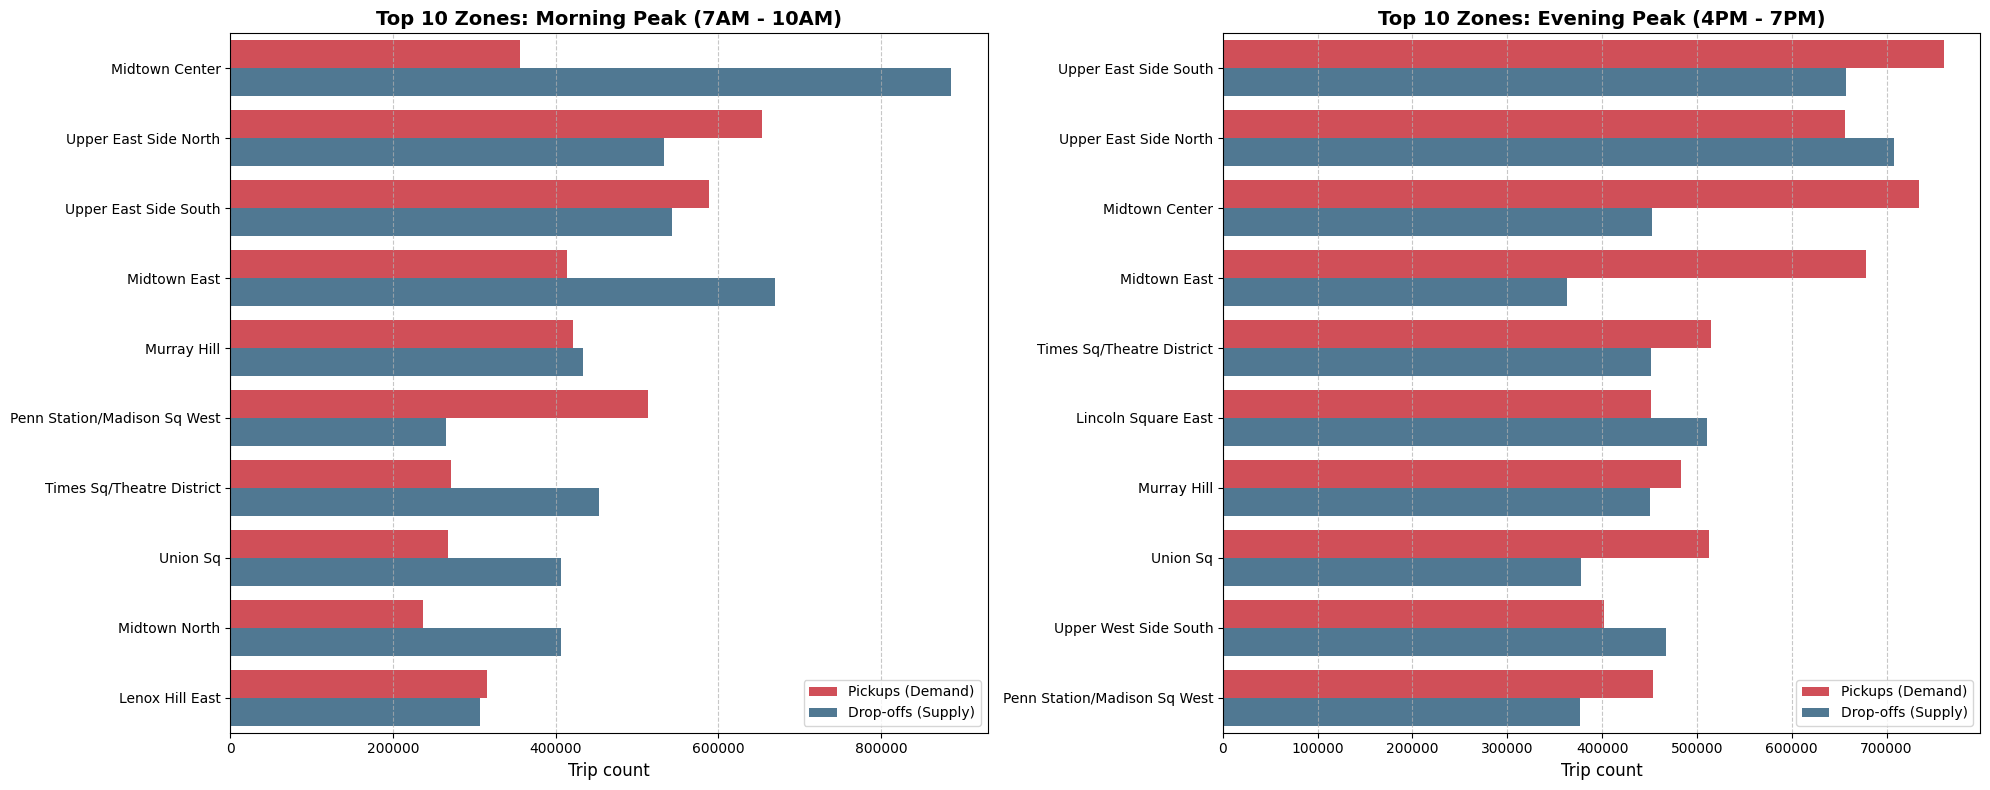

--- AREA WITH SEVERE VEHICLE SHORTAGE (Undersupply - Demand > Supply)---


Zone,peak_period,pickups,dropoffs,net_accumulation
JFK Airport,Evening Peak,471424,131256,-340168
Midtown East,Evening Peak,678763,363230,-315533
LaGuardia Airport,Evening Peak,400535,114392,-286143
Midtown Center,Evening Peak,734135,452975,-281160
Penn Station/Madison Sq West,Morning Peak,514119,265568,-248551



--- SEVERE TRAFFIC CONGESTION AREA (Oversupply - Supply > Demand) ---


Zone,peak_period,pickups,dropoffs,net_accumulation
Midtown Center,Morning Peak,356012,886648,530636
Midtown East,Morning Peak,413752,670105,256353
Times Sq/Theatre District,Morning Peak,271841,453103,181262
Midtown North,Morning Peak,237432,406147,168715
West Chelsea/Hudson Yards,Morning Peak,146807,297462,150655


In [0]:
%python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Top 10 Busiest Zone in Morning Peak and Evening 
query_morning = """
    SELECT Zone, pickups, dropoffs 
    FROM zone_peak_summary 
    WHERE peak_period = 'Morning Peak' 
    ORDER BY total_activity DESC 
    LIMIT 10
"""
query_evening = """
    SELECT Zone, pickups, dropoffs 
    FROM zone_peak_summary 
    WHERE peak_period = 'Evening Peak' 
    ORDER BY total_activity DESC 
    LIMIT 10
"""

df_morning = spark.sql(query_morning).toPandas()
df_evening = spark.sql(query_evening).toPandas()

def plot_peak_imbalance(df, title, ax):
    df_melted = pd.melt(df, id_vars="Zone", var_name="Type", value_name="Trips")
    df_melted['Type'] = df_melted['Type'].map({'pickups': 'Pickups (Demand)', 'dropoffs': 'Drop-offs (Supply)'})
    
    sns.barplot(data=df_melted, y="Zone", x="Trips", hue="Type", palette=["#E63946", "#457B9D"], ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Trip count", fontsize=12)
    ax.set_ylabel("")
    ax.legend(title="")
    
    ax.grid(axis='x', linestyle='--', alpha=0.7)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_peak_imbalance(df_morning, "Top 10 Zones: Morning Peak (7AM - 10AM)", axes[0])
plot_peak_imbalance(df_evening, "Top 10 Zones: Evening Peak (4PM - 7PM)", axes[1])

plt.tight_layout()
plt.show()

print("--- AREA WITH SEVERE VEHICLE SHORTAGE (Undersupply - Demand > Supply)---")
display(spark.sql("SELECT Zone, peak_period, pickups, dropoffs, net_accumulation FROM zone_peak_summary ORDER BY net_accumulation ASC LIMIT 5"))

print("\n--- SEVERE TRAFFIC CONGESTION AREA (Oversupply - Supply > Demand) ---")
display(spark.sql("SELECT Zone, peak_period, pickups, dropoffs, net_accumulation FROM zone_peak_summary ORDER BY net_accumulation DESC LIMIT 5"))

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW monthly_zone_imbalance AS
WITH monthly_imbalance AS (
    SELECT 
        pz.Zone,
        MONTH(t.tpep_pickup_datetime) AS month,
        CASE 
            WHEN HOUR(t.tpep_pickup_datetime) BETWEEN 7 AND 10 THEN 'Morning Peak'
            WHEN HOUR(t.tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 'Evening Peak'
        END AS peak_period,
        COUNT(*) AS total_pickups
    FROM cleaned_trips t
    JOIN taxi_zones pz ON t.PULocationID = pz.LocationID
    WHERE DAYOFWEEK(t.tpep_pickup_datetime) BETWEEN 2 AND 6
      AND pz.Zone IN ('Midtown Center', 'JFK Airport') 
      AND HOUR(t.tpep_pickup_datetime) IN (7, 8, 9, 10, 16, 17, 18, 19)
    GROUP BY pz.Zone, MONTH(t.tpep_pickup_datetime), peak_period
),
dropoffs AS (
    SELECT 
        dz.Zone,
        MONTH(t.tpep_dropoff_datetime) AS month,
        CASE 
            WHEN HOUR(t.tpep_dropoff_datetime) BETWEEN 7 AND 10 THEN 'Morning Peak'
            WHEN HOUR(t.tpep_dropoff_datetime) BETWEEN 16 AND 19 THEN 'Evening Peak'
        END AS peak_period,
        COUNT(*) AS total_dropoffs
    FROM cleaned_trips t
    JOIN taxi_zones dz ON t.DOLocationID = dz.LocationID
    WHERE DAYOFWEEK(t.tpep_dropoff_datetime) BETWEEN 2 AND 6
      AND dz.Zone IN ('Midtown Center', 'JFK Airport')
      AND HOUR(t.tpep_dropoff_datetime) IN (7, 8, 9, 10, 16, 17, 18, 19)
    GROUP BY dz.Zone, MONTH(t.tpep_dropoff_datetime), peak_period
)
SELECT 
    COALESCE(m.Zone, d.Zone) AS Zone,
    COALESCE(m.month, d.month) AS Month,
    COALESCE(m.peak_period, d.peak_period) AS peak_period,
    COALESCE(m.total_pickups, 0) AS pickups,
    COALESCE(d.total_dropoffs, 0) AS dropoffs,
    (COALESCE(d.total_dropoffs, 0) - COALESCE(m.total_pickups, 0)) AS net_accumulation
FROM monthly_imbalance m
FULL OUTER JOIN dropoffs d 
  ON m.Zone = d.Zone AND m.month = d.month AND m.peak_period = d.peak_period
ORDER BY Zone, peak_period, Month;

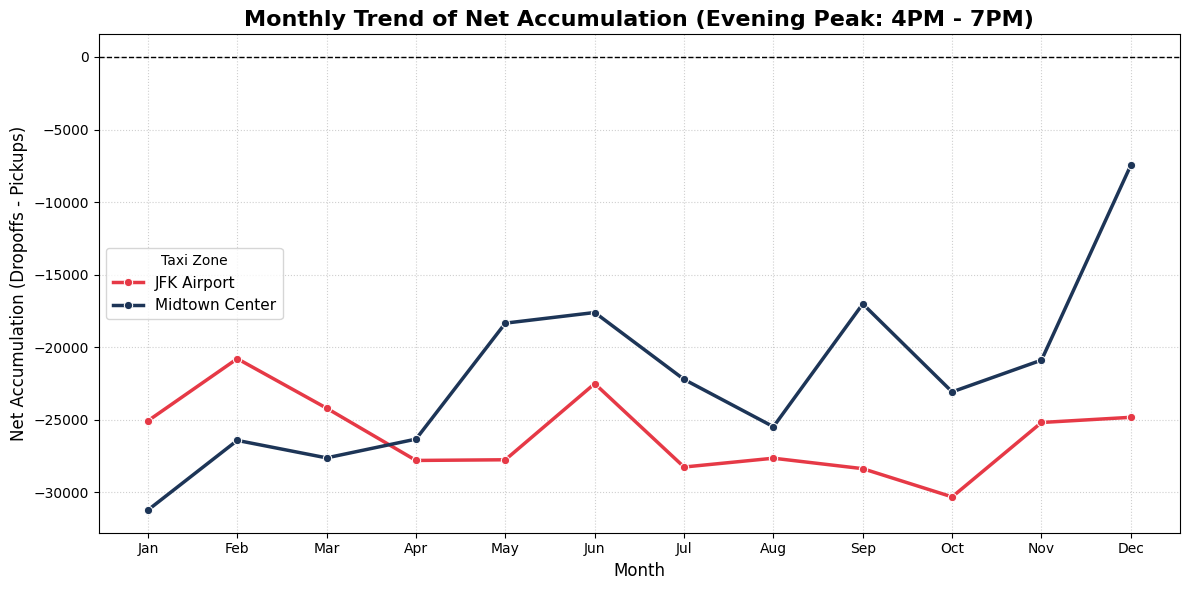

In [0]:
%python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query = """
    SELECT Zone, Month, net_accumulation
    FROM monthly_zone_imbalance
    WHERE peak_period = 'Evening Peak'
    ORDER BY Month
"""
df_monthly = spark.sql(query).toPandas()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_monthly, 
    x='Month', 
    y='net_accumulation', 
    hue='Zone',
    marker='o', 
    linewidth=2.5, 
    palette=['#E63946', '#1D3557'] 
)

plt.title('Monthly Trend of Net Accumulation (Evening Peak: 4PM - 7PM)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Net Accumulation (Dropoffs - Pickups)', fontsize=12)

plt.axhline(0, color='black', linestyle='--', linewidth=1) 

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Taxi Zone', fontsize=11)

plt.tight_layout()
plt.show()

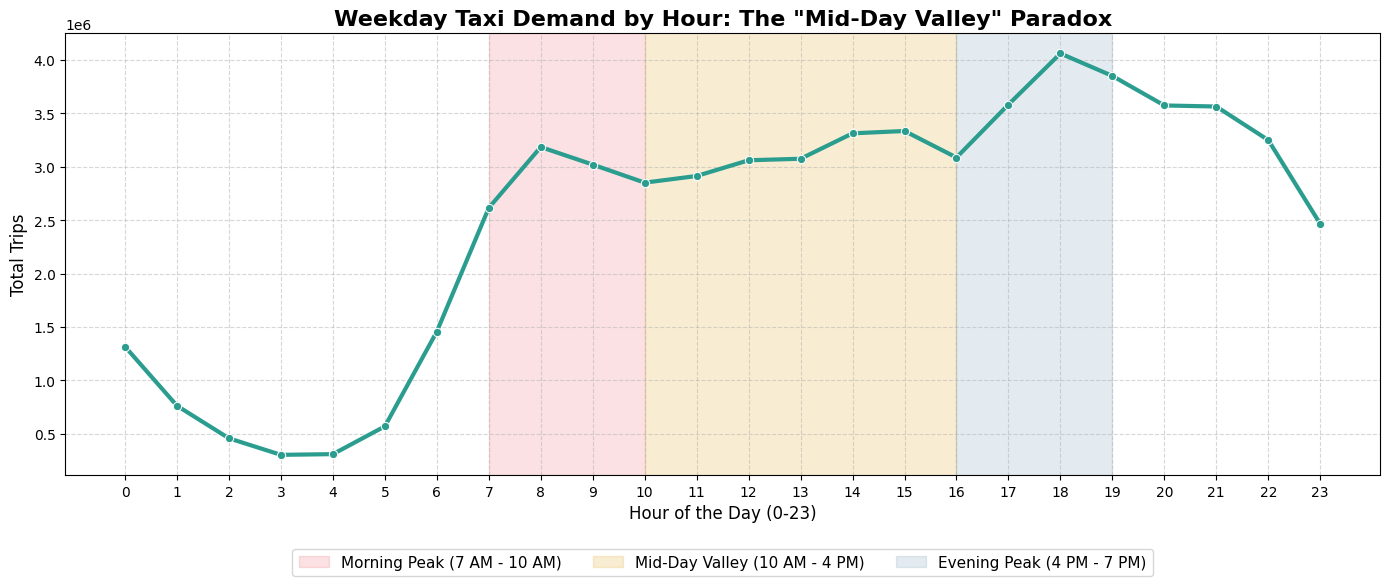

In [0]:
%python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query_hourly = """
    SELECT 
        HOUR(tpep_pickup_datetime) AS hour_of_day,
        COUNT(*) AS total_trips
    FROM cleaned_trips
    WHERE DAYOFWEEK(tpep_pickup_datetime) BETWEEN 2 AND 6
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY hour_of_day
"""

df_hourly = spark.sql(query_hourly).toPandas()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_hourly, 
    x='hour_of_day', 
    y='total_trips', 
    marker='o', 
    linewidth=3, 
    color='#2A9D8F' 
)

plt.axvspan(7, 10, color='#E63946', alpha=0.15, label='Morning Peak (7 AM - 10 AM)')

plt.axvspan(10, 16, color='#E9C46A', alpha=0.3, label='Mid-Day Valley (10 AM - 4 PM)')

plt.axvspan(16, 19, color='#457B9D', alpha=0.15, label='Evening Peak (4 PM - 7 PM)')

plt.title('Weekday Taxi Demand by Hour: The "Mid-Day Valley" Paradox', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=11)

plt.tight_layout()
plt.show()